In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [22]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [23]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [24]:
X=df[['displacement']]
y=df['mpg']
print("Missing values in displacement:",X['displacement'].isnull().sum())
print("Missing values in mpg:",y.isnull().sum())

Missing values in displacement: 0
Missing values in mpg: 0


In [25]:
data=df[['displacement','mpg']].dropna()
X=data[['displacement']]
y=data['mpg']
print("Feature:")
print(X.head())
print("\nTarget")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


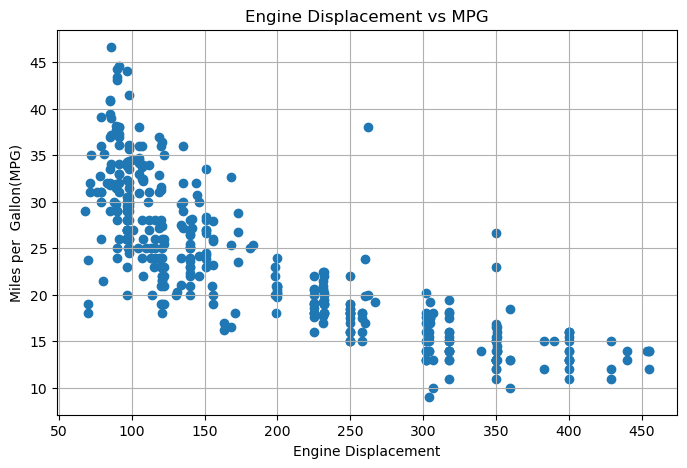

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(X,y)
plt.xlabel("Engine Displacement")
plt.ylabel("Miles per  Gallon(MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()

In [27]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training samples: 318
Testing Samples: 80


In [28]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_linear=linear_model.predict(X_test)

In [29]:
mse_linear=mean_squared_error(y_test,y_pred_linear)
r2_linear=r2_score(y_test,y_pred_linear)
print("Linear Regression Results")
print(".........................")
print("MSE:",mse_linear)
print("R-squared:",r2_linear)

Linear Regression Results
.........................
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [33]:
results=[]
polynomial_models={}
results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
})
for degree in range(2,6):
    poly=PolynomialFeatures(degree=degree)
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)
    poly_model=LinearRegression()
    poly_model.fit(X_train_poly,y_train)
    y_pred_poly=poly_model.predict(X_test_poly)
    mse=mean_squared_error(y_test,y_pred_poly)
    r2=r2_score(y_test,y_pred_poly)
    results.append({
    'Model':'Polynomial Regression',
    'Degree':degree,
    'MSE':mse,
    'R-squared':r2
    })
    polynomial_models[degree]={
        'poly':poly,
        'model':poly_model
    }
    

In [35]:
results_df=pd.DataFrame(results)
results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


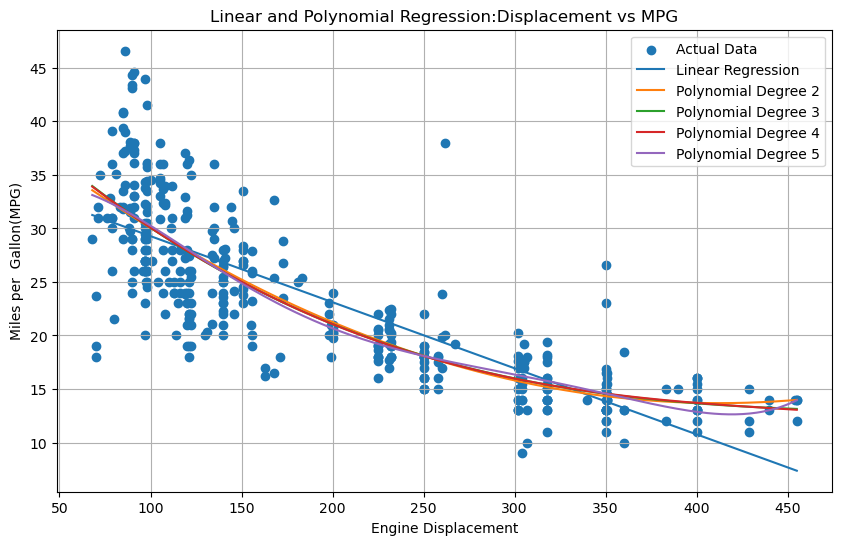

In [49]:
X_plot=pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})
plt.figure(figsize=(10,6))
plt.scatter(X['displacement'],y,label='Actual Data')
y_plot_linear=linear_model.predict(X_plot)
plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'
)
for degree in range(2,6):
    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']
    X_plot_poly=poly.transform(X_plot)
    y_plot_poly=poly_model.predict(X_plot_poly)
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}'
    )
plt.xlabel("Engine Displacement")
plt.ylabel("Miles per  Gallon(MPG)")
plt.title("Linear and Polynomial Regression:Displacement vs MPG")
plt.legend()
plt.grid("TRUE")
plt.show()

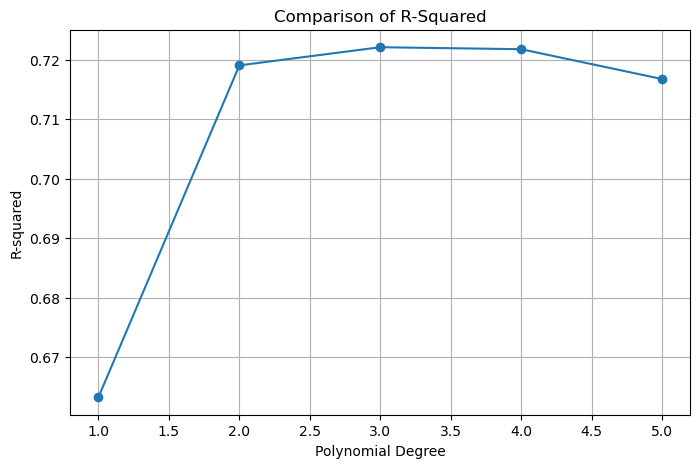

In [55]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-Squared")
plt.grid("TRUE")
plt.show()

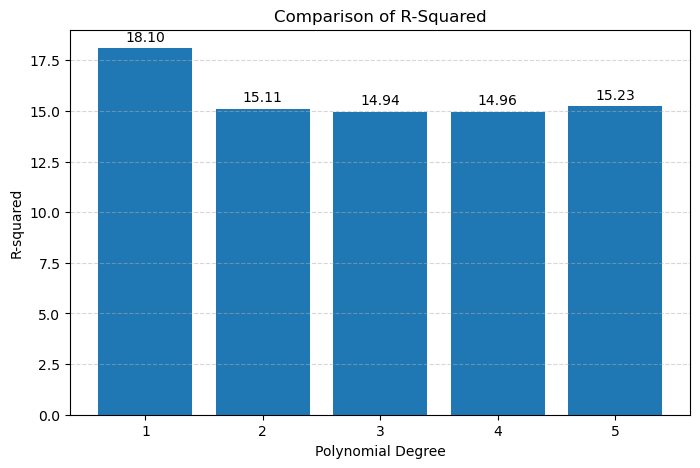

In [59]:
plt.figure(figsize=(8,5))
bars=plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)
plt.bar_label(bars,fmt='%.2f',padding=3)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-Squared")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()